In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from adjustText import adjust_text

In [2]:
# Global theme cho toan bo notebook
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "axes.grid": True,
})

In [3]:
pd.set_option("display.max_columns", None)

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv("Processed_dataset.csv")

# Standardize a few key fields for repeated use across sections
for c in ["DAYS_MISSED", "USG_PCT", "AGE", "PACE", "AVG_SPEED", "GP", "MIN", "POSS", "DRIVES", "FGA_PG"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

for c in ["INJURED_ON", "RETURNED"]:
    if c in df.columns:
        # dayfirst=True handles common sport data formats (dd/mm/yyyy)
        df[c] = pd.to_datetime(df[c], errors="coerce", dayfirst=True)

injury_date_col = "INJURED_ON"
days_col = "DAYS_MISSED"

# Defragment once to avoid pandas PerformanceWarning on later column writes
df = df.copy()

# Injury flag: either valid injury date or days missed > 0 (vectorized once)
injury_from_date = df[injury_date_col].notna() if injury_date_col in df.columns else False
injury_from_days = df[days_col].fillna(0).gt(0) if days_col in df.columns else False
df["injury_flag"] = injury_from_date | injury_from_days

print(f"Rows: {len(df):,}")
print(f"Players: {df['PLAYER_ID'].nunique():,}")
print(f"Teams: {df['TEAM'].nunique():,}")
print(f"Injury rows: {int(df['injury_flag'].sum()):,}")

Rows: 5,572
Players: 1,387
Teams: 30
Injury rows: 1,214


In [4]:
feature = pd.DataFrame(df.columns.tolist())
feature

,0
0,PLAYER_ID
1,PLAYER_NAME
2,SEASON
3,SEASON_NUM
4,AGE
...,...
111,AST_TO_PASS_PCT_ADJ
112,OREB_CHANCE_PCT
113,DREB_CHANCE_PCT
114,REB_CHANCE_PCT_ADJ


## 1) Tần suất vs mức độ nghiêm trọng
- Tần suất: số lần xuất hiện theo loại chấn thương.
- Nghiêm trọng: trung bình số ngày nghỉ (`DAYS MISSED`).

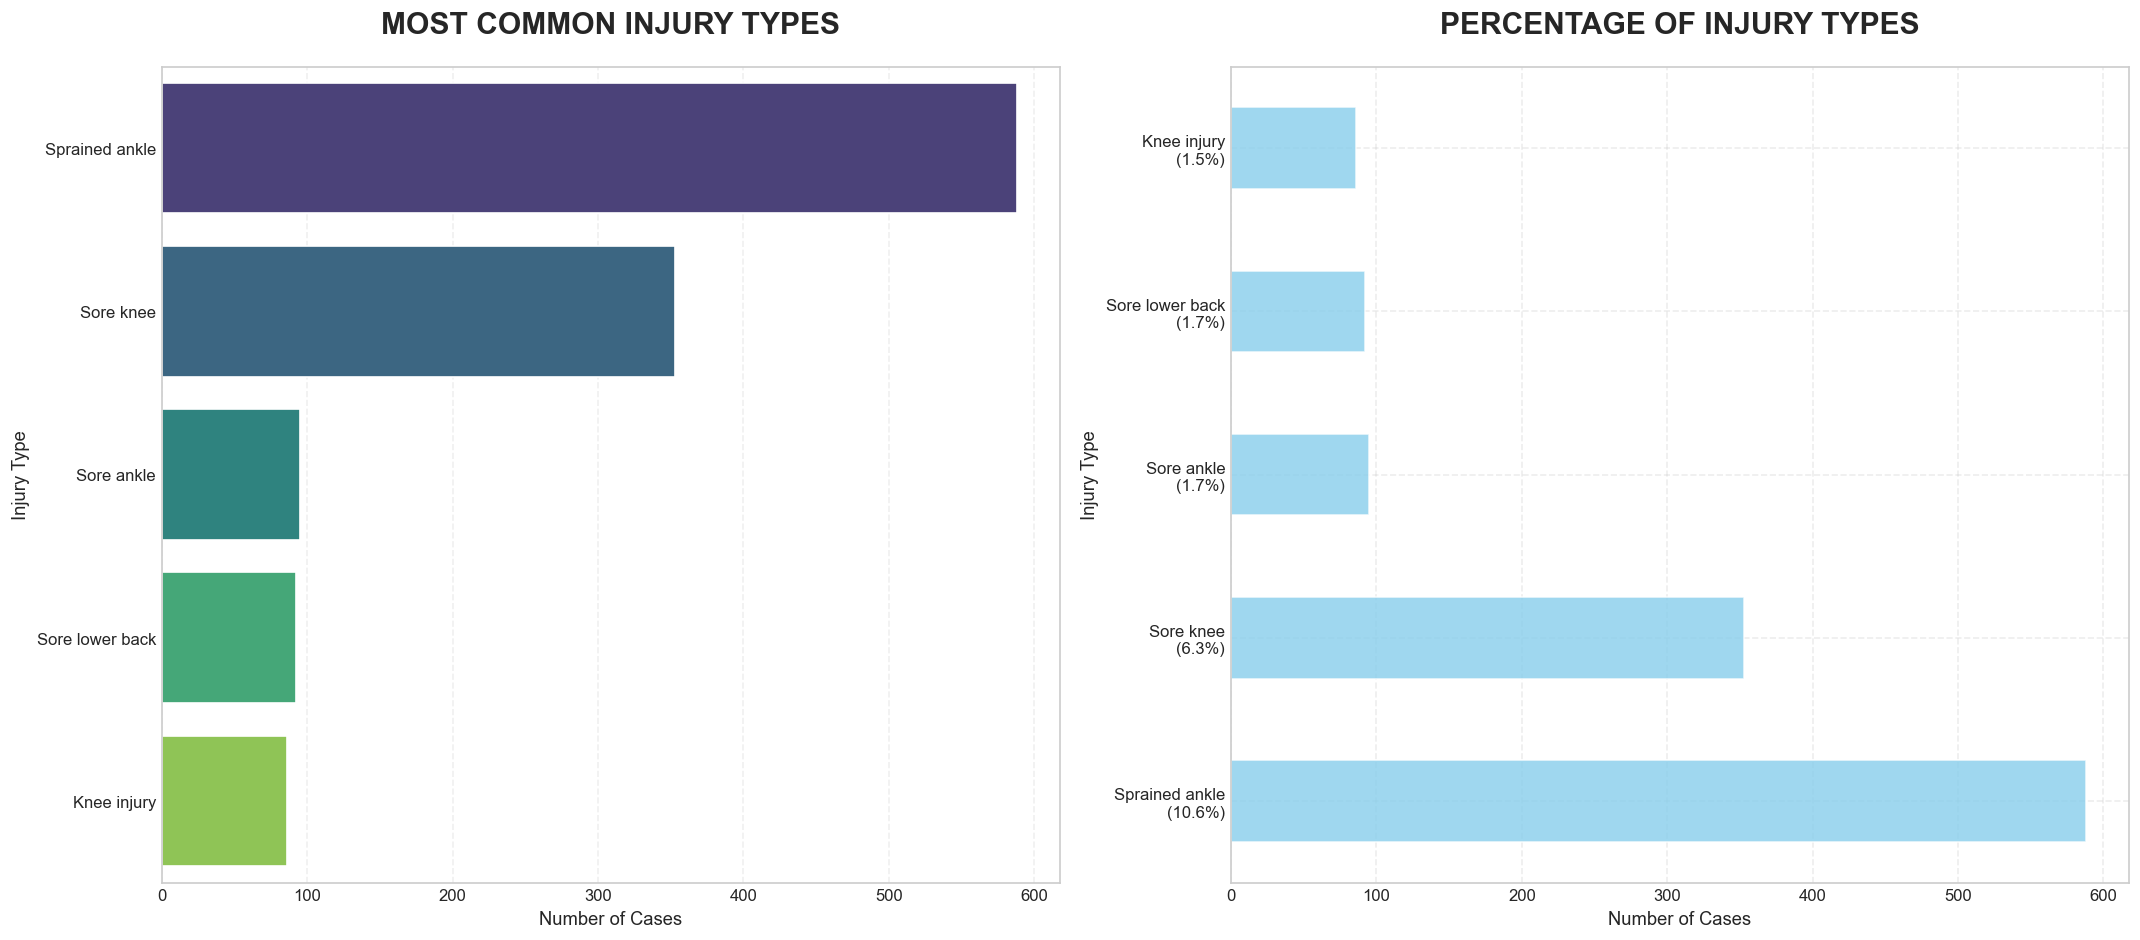

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Top 15 injury types
top_injuries = df['INJURED_TYPE'].dropna().value_counts().head(15)
top_injuries.index = [str(x).replace('_', ' ').strip() for x in top_injuries.index]
plot_left = top_injuries.rename_axis('Injury Type').reset_index(name='Count')

sns.barplot(
    data=plot_left,
    x='Count',
    y='Injury Type',
    hue='Injury Type',
    legend=False,
    ax=ax1,
    palette='viridis'
 )
ax1.set_title('MOST COMMON INJURY TYPES', fontsize=18, pad=20)
ax1.set_xlabel('Number of Cases')
ax1.set_ylabel('Injury Type')
ax1.grid(axis='x', alpha=0.3)

# Horizontal bar + percentage
total = len(df)
percent = (top_injuries / total * 100).round(1)
top_injuries.plot(kind='barh', ax=ax2, color='skyblue', alpha=0.8)
ax2.set_title('PERCENTAGE OF INJURY TYPES', fontsize=18, pad=20)
ax2.set_xlabel('Number of Cases')
ax2.set_ylabel('Injury Type')

# Add percentage to y-axis labels
ax2.set_yticks(range(len(top_injuries.index)))
ax2.set_yticklabels([f"{label}\n({pct}%)" for label, pct in zip(top_injuries.index, percent)])

plt.savefig(OUTPUT_DIR / 'top_injuries.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

,COUNT,MAX,MIN,MEDIAN,MEAN,STD
DAYS_MISSED,1214,282.0,1.0,4.0,8.752059,18.313393


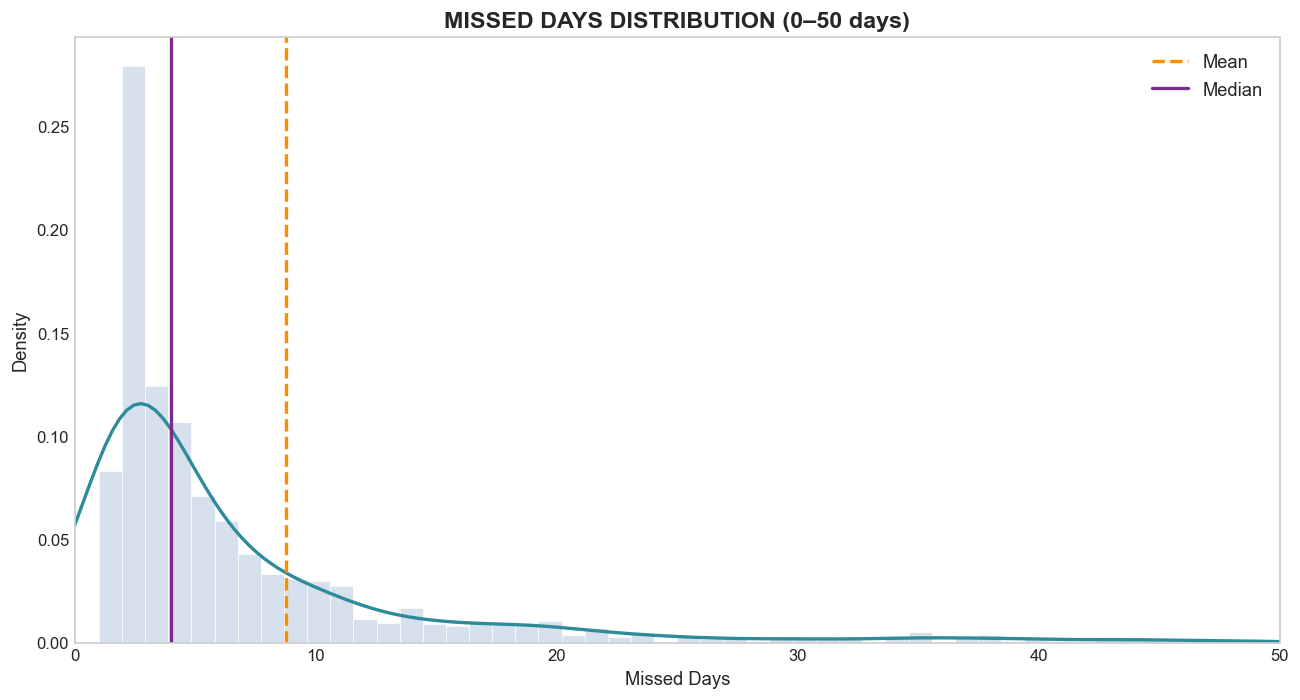

<Figure size 1440x720 with 0 Axes>

In [6]:
missed_col = "MISSED_DAYS" if "MISSED_DAYS" in df.columns else "DAYS_MISSED"

if missed_col not in df.columns:
    print(f"Thiếu cột {missed_col}")
else:
    # ===== Clean data =====
    missed_df = df[[missed_col]].copy()
    missed_df[missed_col] = pd.to_numeric(missed_df[missed_col], errors="coerce")
    missed_df = missed_df.dropna(subset=[missed_col])
    missed_df = missed_df[missed_df[missed_col] >= 0]

    if missed_df.empty:
        print("Không có dữ liệu hợp lệ để vẽ.")
    else:
        # ===== Summary stats =====
        stats_df = pd.DataFrame({
            "COUNT": [missed_df[missed_col].count()],
            "MAX": [missed_df[missed_col].max()],
            "MIN": [missed_df[missed_col].min()],
            "MEDIAN": [missed_df[missed_col].median()],
            "MEAN": [missed_df[missed_col].mean()],
            "STD": [missed_df[missed_col].std()],
        }, index=[missed_col])

        display(stats_df)

        # ===== Truncate (giữ bulk distribution) =====
        cutoff = 50
        plot_df = missed_df[missed_df[missed_col] <= cutoff]

        # ===== Plot =====
        plt.figure(figsize=(11, 6))

        # Histogram (background)
        sns.histplot(
            data=plot_df,
            x=missed_col,
            bins=50,
            stat="density",
            color="#B0C4DE",
            alpha=0.5,
            edgecolor="white",
            linewidth=0.4
        )

        # KDE (main signal)
        sns.kdeplot(
            data=plot_df,
            x=missed_col,
            color="#2E8B9A",
            linewidth=2
        )

        # Mean (full data)
        plt.axvline(
            missed_df[missed_col].mean(),
            color="#FF8C00",
            linestyle="--",
            linewidth=2,
            label="Mean"
        )

        # Median (full data)
        plt.axvline(
            missed_df[missed_col].median(),
            color="#7B2D8B",
            linestyle="-",
            linewidth=2,
            label="Median"
        )

        plt.title("MISSED DAYS DISTRIBUTION (0–50 days)", fontsize=14, fontweight="bold")
        plt.xlabel("Missed Days")
        plt.ylabel("Density")
        plt.xlim(0, cutoff)
        plt.grid( visible=False)
     
        plt.legend()
        plt.tight_layout()
        plt.show()
        plt.savefig(OUTPUT_DIR / "missed_days_distribution.png", dpi=300, bbox_inches="tight")
        # ===== Save stats =====
        stats_df.to_csv(OUTPUT_DIR / "missed_days_stats.csv", index=False)

In [7]:
# Plot lớn hơn: mỗi loại chấn thương là 1 figure riêng + KDE
inj_col = "INJURED_TYPE"
missed_col = "MISSED_DAYS" if "MISSED_DAYS" in df.columns else "DAYS_MISSED"

def format_injury_name(value):
    return str(value).replace("_", " ").strip().title().upper()

if inj_col not in df.columns or missed_col not in df.columns:
    print(f"Thiếu cột bắt buộc: {inj_col} hoặc {missed_col}")
else:
    plot_df = df[[inj_col, missed_col]].copy()
    plot_df[missed_col] = pd.to_numeric(plot_df[missed_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[inj_col, missed_col])
    plot_df = plot_df[plot_df[missed_col] >= 0]

    if plot_df.empty:
        print("Không có dữ liệu hợp lệ để vẽ.")
    else:
        top5_inj = plot_df[inj_col].value_counts().head(5).index.tolist()

        stats_df = (
            plot_df.groupby(inj_col)[missed_col]
            .agg(["count", "max", "min", "mean", "median", "std"])
            .rename(columns={
                "count": "COUNT",
                "max": "MAX",
                "min": "MIN",
                "mean": "MEAN",
                "median": "MEDIAN",
                "std": "STD"
            })
            .reset_index()
        )
        stats_df[inj_col] = stats_df[inj_col].map(format_injury_name)
        stats_df = stats_df.rename(columns={inj_col: "INJURED_TYPE"})

        display(stats_df)

stats_df.to_csv(OUTPUT_DIR / "injury_missed_days_stats.csv", index=False)

,INJURED_TYPE,COUNT,MAX,MIN,MEAN,MEDIAN,STD
0,KNEE INJURY,86,282.0,1.0,15.279070,2.5,40.088036
1,SORE ANKLE,95,34.0,1.0,4.873684,3.0,4.916845
2,SORE KNEE,353,212.0,1.0,6.458924,3.0,13.832773
3,SORE LOWER BACK,92,55.0,1.0,5.891304,3.5,8.093487
4,SPRAINED ANKLE,588,177.0,1.0,10.248299,5.0,17.782126


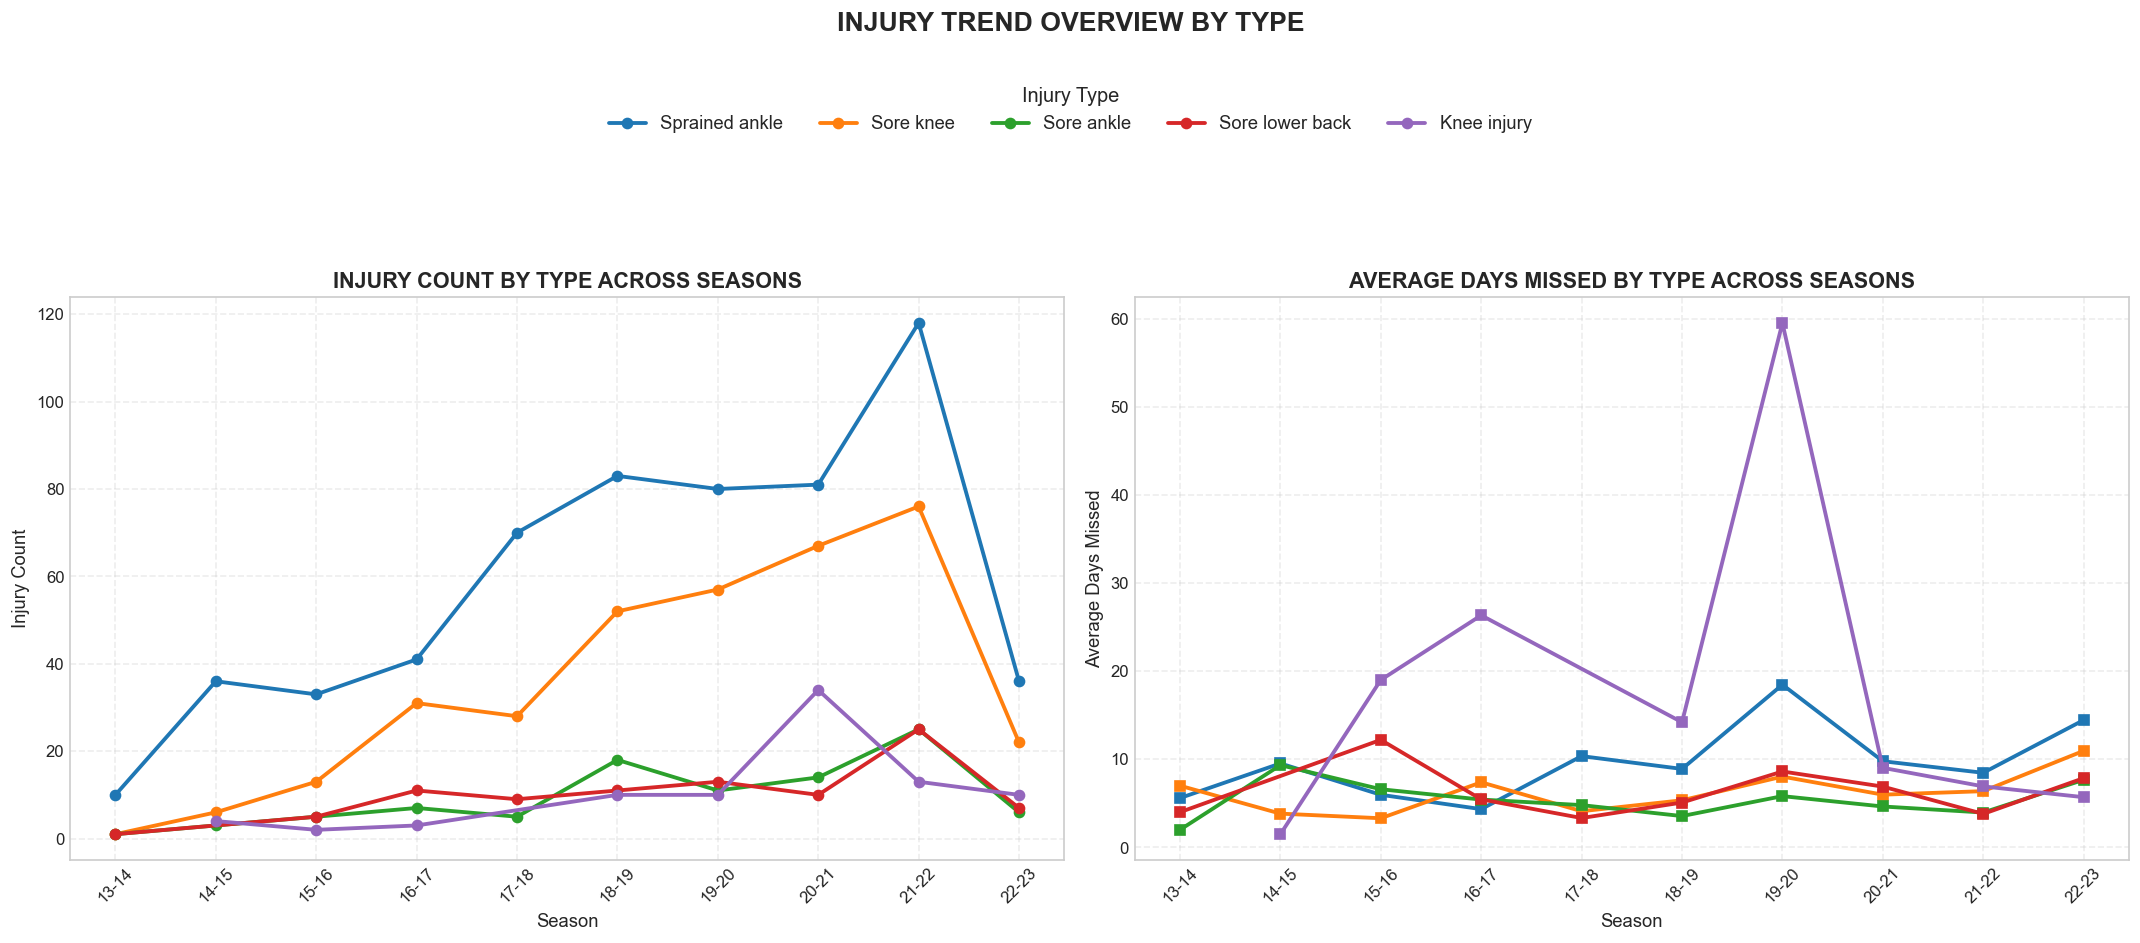

In [8]:
df_clean = df.dropna(subset=['INJURED_TYPE', 'SEASON', 'DAYS_MISSED'])

# 1) Lấy Top 5 loại chấn thương xuất hiện nhiều nhất
top_5_types = df_clean['INJURED_TYPE'].value_counts().nlargest(5).index.tolist()
df_top5 = df_clean[df_clean['INJURED_TYPE'].isin(top_5_types)].copy()

# 2) Tạo dữ liệu cho cả 2 chỉ số
seasonal_counts = (
    df_top5.groupby(['SEASON', 'INJURED_TYPE'])
    .size()
    .reset_index(name='INJURY_COUNT')
)

seasonal_avg = (
    df_top5.groupby(['SEASON', 'INJURED_TYPE'])['DAYS_MISSED']
    .mean()
    .reset_index(name='AVG_DAYS_MISSED')
)

merged = seasonal_counts.merge(
    seasonal_avg,
    on=['SEASON', 'INJURED_TYPE'],
    how='inner'
)
merged['INJURED_TYPE_LABEL'] = merged['INJURED_TYPE'].str.replace('_', ' ', regex=False).str.strip()
merged = merged.sort_values('SEASON')

# 3) 1 figure gồm 2 plot khác nhau đặt cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True)
ax1, ax2 = axes

palette = sns.color_palette('tab10', n_colors=len(top_5_types))
color_map = {t: palette[i] for i, t in enumerate(top_5_types)}

for inj_type in top_5_types:
    sub = merged[merged['INJURED_TYPE'] == inj_type]
    label = inj_type.replace('_', ' ').strip()
    color = color_map[inj_type]

    ax1.plot(
        sub['SEASON'],
        sub['INJURY_COUNT'],
        marker='o',
        linewidth=2.3,
        color=color,
        label=label
    )

    ax2.plot(
        sub['SEASON'],
        sub['AVG_DAYS_MISSED'],
        marker='s',
        linewidth=2.3,
        color=color,
        label=label
    )

ax1.set_title('INJURY COUNT BY TYPE ACROSS SEASONS', fontsize=13, fontweight='bold')
ax1.set_xlabel('Season', fontsize=11)
ax1.set_ylabel('Injury Count', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.35)
ax1.tick_params(axis='x', rotation=45)

ax2.set_title('AVERAGE DAYS MISSED BY TYPE ACROSS SEASONS', fontsize=13, fontweight='bold')
ax2.set_xlabel('Season', fontsize=11)
ax2.set_ylabel('Average Days Missed', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.35)
ax2.tick_params(axis='x', rotation=45)

# 1 legend duy nhất cho cả figure
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, title='Injury Type', loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=5)

fig.suptitle('INJURY TREND OVERVIEW BY TYPE', fontsize=16, fontweight='bold', y=1.12)
fig.tight_layout()
fig.subplots_adjust(top=0.78)

plt.savefig(OUTPUT_DIR / 'injury_trends_two_subplots_one_figure.png', dpi=300, bbox_inches='tight')
# print("Đã lưu biểu đồ vào file 'injury_trends_two_subplots_one_figure.png'")

# Xuất bảng số liệu để tham khảo
pivot_count = merged.pivot(index='SEASON', columns='INJURED_TYPE_LABEL', values='INJURY_COUNT').fillna(0)
pivot_avg = merged.pivot(index='SEASON', columns='INJURED_TYPE_LABEL', values='AVG_DAYS_MISSED').fillna(0)
# print("\nBảng số ca chấn thương:")
# print(pivot_count)
# print("\nBảng số ngày nghỉ trung bình:")
# print(pivot_avg.round(2))
plt.show()

## 3) Tuổi tác ảnh hưởng như thế nào
Xem phân phối ngày nghỉ theo nhóm tuổi và xu hướng tổng quát giữa tuổi với `DAYS MISSED`.

In [11]:
# 1. Xử lý các cột chuỗi để tránh lỗi khi gộp (NaN sẽ được thay bằng 'None')
cols_to_fill = ['INJURED_ON', 'RETURNED', 'INJURED_TYPE']
for col in cols_to_fill:
    df[col] = df[col].fillna('None').astype(str)

# 2. Thực hiện gộp dữ liệu theo Player, Season và Age
# Ta dùng lambda để nối các chuỗi chấn thương lại với nhau bằng dấu gạch đứng "|"
df_clean = df.groupby(['PLAYER_ID', 'SEASON', 'AGE'], as_index=False).agg({
    'MIN': 'first',                 # Giữ nguyên số phút, không cộng dồn
    'DAYS_MISSED': 'sum',           # Cộng tổng tất cả các đợt nghỉ trong mùa
    'INJURED_TYPE': lambda x: ' | '.join(dict.fromkeys(x)), # Nối các loại, loại bỏ trùng tên
    'INJURED_ON': lambda x: ' | '.join(dict.fromkeys(x)),
    'RETURNED': lambda x: ' | '.join(dict.fromkeys(x))
})

# 3. Tính toán EDA trên tập dữ liệu đã làm sạch
# Ví dụ: Tính Rate theo nhóm tuổi
age_stats = df_clean.groupby('AGE').agg({'MIN': 'sum', 'DAYS_MISSED': 'sum'})
age_stats['rate_1000min'] = (age_stats['DAYS_MISSED'] / age_stats['MIN']) * 1000

display(age_stats.reset_index())

,AGE,MIN,DAYS_MISSED,rate_1000min
0,19.0,821.7,28.0,34.075697
1,20.0,3219.1,276.0,85.738250
2,21.0,5270.8,996.0,188.965622
3,22.0,7061.2,997.0,141.194131
4,23.0,8918.2,1084.0,121.549192
5,24.0,9989.9,700.0,70.070771
6,25.0,9481.0,1068.0,112.646345
7,26.0,8838.3,694.0,78.521888
8,27.0,8339.2,914.0,109.602840
9,28.0,7808.1,1090.0,139.598622


Heatmap với mục tiêu là missed days

In [10]:
if injury_date_col in df.columns:
    # 1. Tiền xử lý dữ liệu thời gian
    season_df = df[df[injury_date_col].notna()].copy()
    season_df["injury_month"] = season_df[injury_date_col].dt.month

    # 2. Ánh xạ giai đoạn mùa giải sang Tiếng Việt
    # Logic: Phân nhóm các tháng rời rạc vào các giai đoạn có tính thứ tự
    phase_map = {
        10: "Đầu mùa", 11: "Đầu mùa", 12: "Đầu mùa",
        1: "Giữa mùa", 2: "Giữa mùa", 3: "Giữa mùa",
        4: "Cuối mùa", 5: "Cuối mùa", 6: "Cuối mùa",
        7: "Ngoài mùa", 8: "Ngoài mùa", 9: "Ngoài mùa"
    }
    season_df["season_phase"] = season_df["injury_month"].map(phase_map).fillna("Không xác định")

    # Tính toán thống kê
    month_counts = season_df["injury_month"].value_counts().sort_index()
    phase_counts = season_df["season_phase"].value_counts()

    # 3. Khởi tạo biểu đồ
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Biểu đồ trái: Theo tháng (Sử dụng bảng màu 'flare' để tạo chiều sâu)
    sns.barplot(
        x=month_counts.index,
        y=month_counts.values,
        ax=axes[0],
        palette="flare",
        hue=month_counts.index,
        legend=False
    )
    axes[0].set_title("Số lượng chấn thương theo tháng", fontsize=14, weight='bold', pad=15)
    axes[0].set_xlabel("Tháng", fontsize=11)
    axes[0].set_ylabel("Số lượng ca", fontsize=11)

    # Biểu đồ phải: Theo giai đoạn (Sử dụng bảng màu 'viridis' chuyên nghiệp)
    order = ["Đầu mùa", "Giữa mùa", "Cuối mùa", "Ngoài mùa"]
    phase_plot = phase_counts.reindex(order).fillna(0)

    sns.barplot(
        x=phase_plot.index,
        y=phase_plot.values,
        ax=axes[1],
        palette="mako",
        hue=phase_plot.index,
        legend=False
    )
    axes[1].set_title("Số lượng chấn thương theo giai đoạn mùa giải", fontsize=14, weight='bold', pad=15)
    axes[1].set_xlabel("Giai đoạn", fontsize=11)
    axes[1].set_ylabel("Số lượng ca", fontsize=11)

    # Tinh chỉnh cuối cùng
    sns.despine(left=True)
    plt.tight_layout()
    plt.show()
else:
    print(f"Lỗi: Không tìm thấy cột ngày chấn thương '{injury_date_col}' trong dữ liệu.")

AttributeError: Can only use .dt accessor with datetimelike values